# Readymade Data Module Assignment
## NYC 311 Service Request Analysis

**Student Name:** Zejun Li

**U-M Unique Name:** zejunli

**Research Question:** State your chosen research question here
Option 1: Neighborhood Service Request Signatures - Do different neighborhoods have distinctive patterns in their 311 service requests? Analyze the relative frequency of complaint types across neighborhoods. What patterns do you notice?

---

**BEFORE YOU START:**
1. Read the assignment instructions on Canvas carefully.
2. Make a copy of this notebook and work on your own copy.
3. Understand the dataset before you start cleaning and analyzing. NYC Open Data has a nice portal and a data dictionary for exploring their datasets.
4. NYC 311 is a **very large** dataset. When you are fetching data from the portal or API, we would recommend you to first think about your research questions and start with a small subset of the data and then increase the size of the data as you get more comfortable with the data. Generally, you do **not** need to use the entire dataset to answer your research question.
5. This notebook serves as a template. You can add more cells or make adjustments as you see fit. But make sure to keep all the sections mentioned in the assignment instructions. Also, format your notebook properly for better readability.

## Data Statement

Describe your data source here. Include:
- Where you obtained the data (URL or API endpoint)
- What subset you're analyzing (dates, geography, etc.)
- Any filters or sampling you applied
- File size/number of records


The data for this analysis comes from the NYC Open Data portal, specifically the 311 Service Requests dataset, accessed via the Socrata Open Data API: https://data.cityofnewyork.us/resource/erm2-nwe9.json.

Due to the large size of the full dataset (40+ million records), I retrieved a subset of the data using the API. I limited the sample to service requests created between January 1, 2023 and December 31, 2023, and set a maximum retrieval limit of 100,000 records to ensure the dataset remained manageable for analysis.

After downloading the data, I filtered the dataset to include only records from the five NYC boroughs (Manhattan, Brooklyn, Queens, Bronx, and Staten Island). I also removed observations with missing values for key variables such as created_date, borough, and complaint_type.

The final cleaned dataset contains 99,756 records. This subset provides a manageable yet substantial sample for examining borough-level complaint pattern. 


## 1. Setup and Data Loading

In [47]:
# Import libraries
# You can import any libraries you may need
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from scipy.spatial.distance import pdist, squareform

# Set visualization style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

# Display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

### Option A: Load from downloaded CSV file

**Note**: If you are running the notebook using `colab` kernel, you **cannot** directly import the data from your own laptop. Please see the class repo README files for more details

In [48]:
# Load your downloaded data
# df = pd.read_csv('311_Service_Requests.csv', 
#                  parse_dates='Created Date', 'Closed Date',
#                  low_memory=False)

### Option B: Load from Socrata API (recommended for smaller datasets)

In [49]:
# !pip install sodapy # UNCOMMENT THIS LINE IF YOU NEED TO INSTALL sodapy: 

from sodapy import Socrata

client = Socrata("data.cityofnewyork.us", None, timeout=30)

# Retrieve a subset of 311 service requests from 2023
results = client.get(
    "erm2-nwe9",
    where="created_date >= '2023-01-01' AND created_date < '2024-01-01'",
    limit=100000
)

# Convert returned records into a pandas DataFrame
df = pd.DataFrame.from_records(results)

# Convert date column for filtering and analysis
df['created_date'] = pd.to_datetime(df['created_date'], errors='coerce')

## 2.Data Description

You can describe the data in many ways. Here are some baseline requirements:
- Display basic information about the dataset (what are the relevant variables? What are their types? How many observations are there?)
- Conduct summary statistics of the relevant variables
- Check for missing values

In [50]:
# You can have as many cells as you want
# Basic structure
df.info()

# Check missing values
df.isna().sum()

# Summary statistics for key categorical variables
df['borough'].value_counts()
df['complaint_type'].value_counts().head(10)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 44 columns):
 #   Column                          Non-Null Count   Dtype         
---  ------                          --------------   -----         
 0   unique_key                      100000 non-null  object        
 1   created_date                    100000 non-null  datetime64[ns]
 2   closed_date                     99457 non-null   object        
 3   agency                          100000 non-null  object        
 4   agency_name                     100000 non-null  object        
 5   complaint_type                  100000 non-null  object        
 6   descriptor                      99184 non-null   object        
 7   location_type                   86489 non-null   object        
 8   incident_zip                    98747 non-null   object        
 9   incident_address                95114 non-null   object        
 10  street_name                     95114 non-null   object  

,count
complaint_type,
Illegal Parking,15394
HEAT/HOT WATER,11396
Noise - Residential,8691
Blocked Driveway,5574
UNSANITARY CONDITION,3801
Street Condition,2813
PLUMBING,2313
Noise - Street/Sidewalk,2302
Abandoned Vehicle,2232


## 3. Data Cleaning

Document your cleaning decisions and rationale here

In [51]:
# Remove rows with missing essential data
df_clean = df.dropna(subset=['created_date', 'borough', 'complaint_type'])

# Filter to specific time period (2023)
df_clean = df_clean[
    (df_clean['created_date'] >= '2023-01-01') &
    (df_clean['created_date'] < '2024-01-01')
]

# Keep only the five NYC boroughs
df_clean = df_clean[df_clean['borough'].isin([
    'MANHATTAN', 'BROOKLYN', 'QUEENS', 'BRONX', 'STATEN ISLAND'
])]

# Dataset changes
original_len = len(df)
cleaned_len = len(df_clean)
removed_len = original_len - cleaned_len
removed_pct = (removed_len / original_len) * 100

print(f"Original dataset: {original_len} records")
print(f"Cleaned dataset: {cleaned_len} records")
print(f"Removed: {removed_len} records ({removed_pct:.1f}%)")


Original dataset: 100000 records
Cleaned dataset: 99756 records
Removed: 244 records (0.2%)


## 4.Exploratory Data Analysis

Add narrative about what you're exploring, why and what you've found

In this section, I explore the overall distribution of 311 complaint types and how service request volumes vary across the five boroughs. This preliminary analysis helps me identify dominant complaint categories and provide context for comparing relative complaint patterns across neighborhoods in the focused analysis later. I found that the most common 311 complaint types across the boroughs in 2023 were 1. Illegal Parking, 2. Heat/hot water, and 3. Noise - Residential. I also discovered that Brooklyn had the greatest number of total 311 compalints.

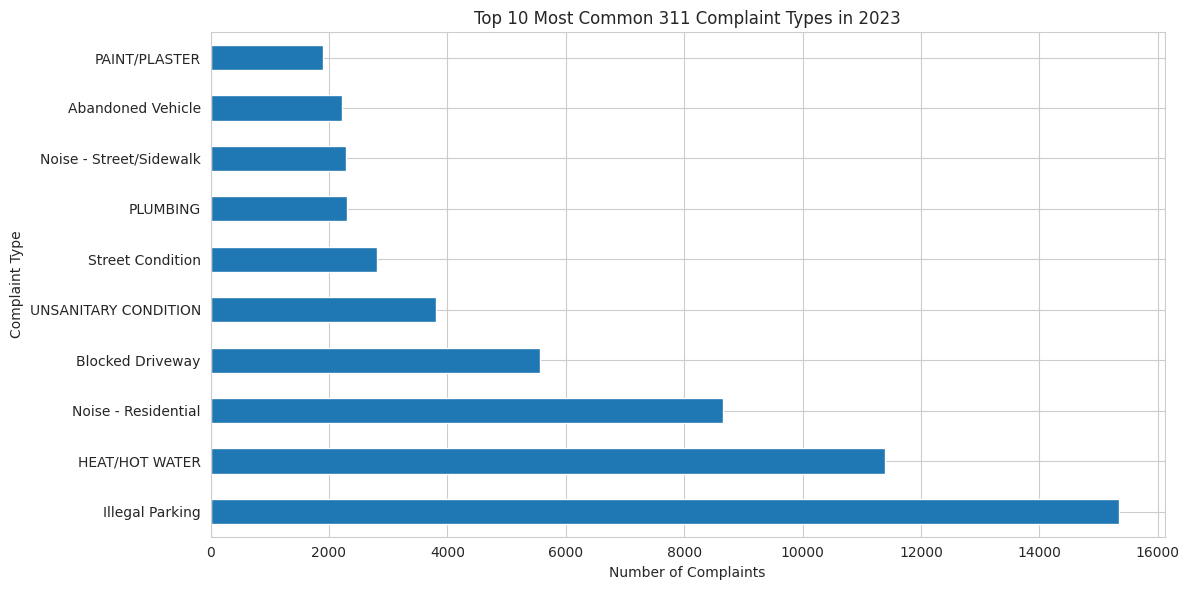

In [52]:
# Most common complaint types across all boroughs
complaint_counts = df_clean['complaint_type'].value_counts().head(10)

plt.figure(figsize=(12, 6))
complaint_counts.plot(kind='barh')
plt.xlabel('Number of Complaints')
plt.ylabel('Complaint Type')
plt.title('Top 10 Most Common 311 Complaint Types in 2023')
plt.tight_layout()
plt.show()

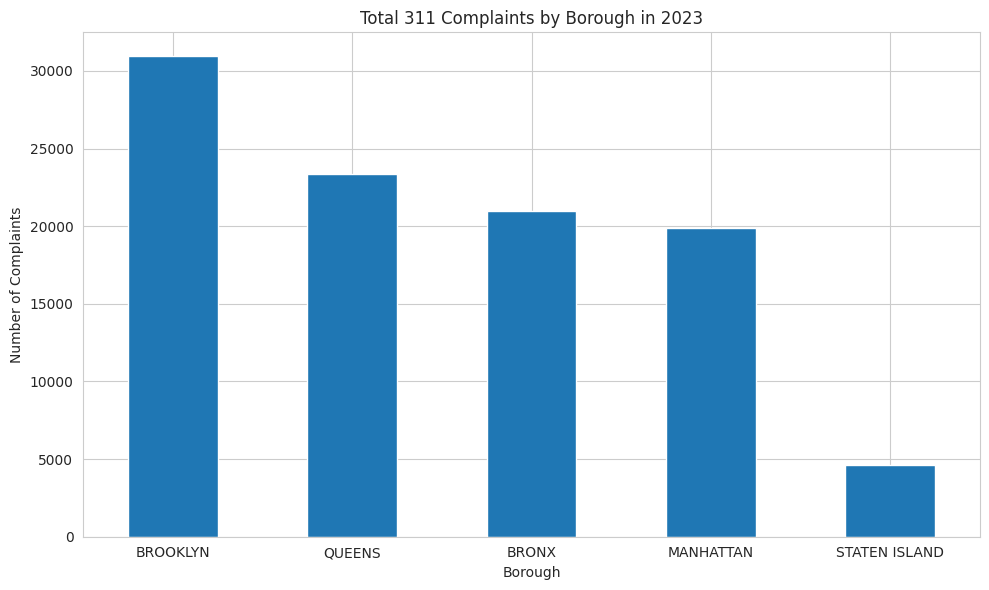

In [53]:
# Total number of 311 complaints by borough
borough_counts = df_clean['borough'].value_counts()

plt.figure(figsize=(10, 6))
borough_counts.plot(kind='bar')
plt.xlabel('Borough')
plt.ylabel('Number of Complaints')
plt.title('Total 311 Complaints by Borough in 2023')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 5.Research Question Analysis

This is the core of your assignment. Document your analytical approach here. You can add any cells if you see fit.

In [54]:
# Your focused analysis goes here
# This will vary significantly based on your research question. You can organize your analysis as you like. You can have as many cells as you want.

To examine whether neighborhoods exhibit distinct 311 service request signatures, I compare the relative frequency of complaint types across boroughs. Using proportions rather than raw counts allows for meaningful comparisons that are not driven solely by population size or reporting volume.

In [55]:
# Count complaints by borough and complaint type
borough_complaints = (
    df_clean
    .groupby(['borough', 'complaint_type'])
    .size()
    .reset_index(name='count')
)

# Convert counts to proportions within each borough
borough_complaints['proportion'] = (
    borough_complaints['count'] /
    borough_complaints.groupby('borough')['count'].transform('sum')
)

borough_complaints.head()

,borough,complaint_type,count,proportion
0,BRONX,APPLIANCE,305,0.014555
1,BRONX,Abandoned Bike,3,0.000143
2,BRONX,Abandoned Vehicle,367,0.017514
3,BRONX,Adopt-A-Basket,1,0.000048
4,BRONX,Air Quality,17,0.000811


## Key Visualizations

Create at least 3 polished visualizations that answer your research question

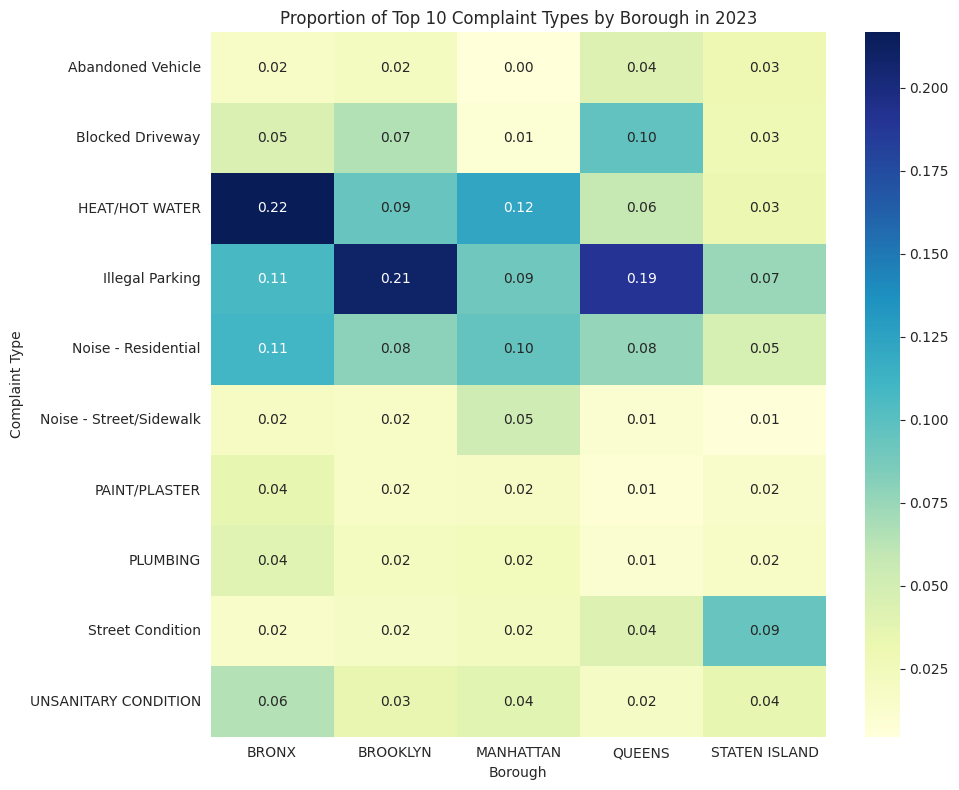

In [56]:
# Select top 10 complaint types overall to keep visualization readable
top10_types = df_clean['complaint_type'].value_counts().head(10).index

heatmap_data = (
    borough_complaints[borough_complaints['complaint_type'].isin(top10_types)]
    .pivot(index='complaint_type', columns='borough', values='proportion')
    .fillna(0)
)

plt.figure(figsize=(10, 8))
sns.heatmap(heatmap_data, annot=True, fmt=".2f", cmap="YlGnBu")
plt.title("Proportion of Top 10 Complaint Types by Borough in 2023")
plt.xlabel("Borough")
plt.ylabel("Complaint Type")
plt.tight_layout()
plt.show()

Interpretation of Visualization 1: This heatmap shows the relative frequency of the ten most common complaint types across boroughs. Clear differences emerge in borough signatures. For example, HEAT/HOT WATER complaints are dominant in the Bronx, representing over 21% of all complaints there; this is noticeably higher than in other boroughs. In contrast, Illegal Parking is most dominant in Brooklyn and Queens, where it accounts for roughly 20% of complaints. Manhattan stands out for nise-related complaints, particularly Noise - Street/Sidewalk and Noise - Helicopter, which may be owed to a denser urban environment with nightlife and tourism activity.
These differences suggest that boroughs have distinct service request compositions rather than simply varying in total volume.

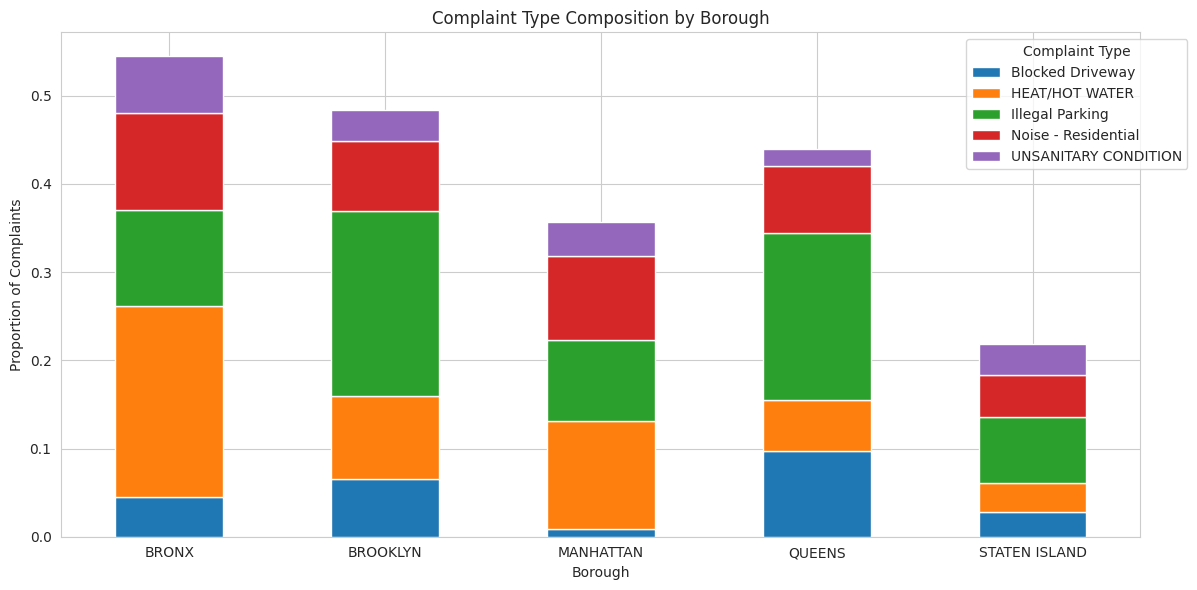

In [57]:
# Visualization 2  - Borough complaint composition

# Keep top 5 complaint types per borough
top5_types = (
    df_clean['complaint_type']
    .value_counts()
    .head(5)
    .index
)

stacked_data = (
    borough_complaints[borough_complaints['complaint_type'].isin(top5_types)]
    .pivot(index='borough', columns='complaint_type', values='proportion')
    .fillna(0)
)

stacked_data.plot(kind='bar', stacked=True)
plt.title("Complaint Type Composition by Borough")
plt.ylabel("Proportion of Complaints")
plt.xlabel("Borough")
plt.xticks(rotation=0)
plt.legend(title="Complaint Type", bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

Interpretation of Visualization 2: This stacked bar chart illustrates the composition of the five most common complaint types within each borough. The Bronx is heavily dominated by HEAT/HOT WATER complaints, while Brooklyn and Queens show a larger share of Illegal Parking complaints. Manhattan exhibits a more balanced distribution across complaint types but has a notably higher share of noise-related issues. Staten Island shows a different structure altogether, with relatively higher proportions of waste-related and street condition complaints. These patterns reinforce the idea that boroughs exhibit distinctive complaint profiles that may reflect differences in housing conditions, density, infrastructure, and land use.

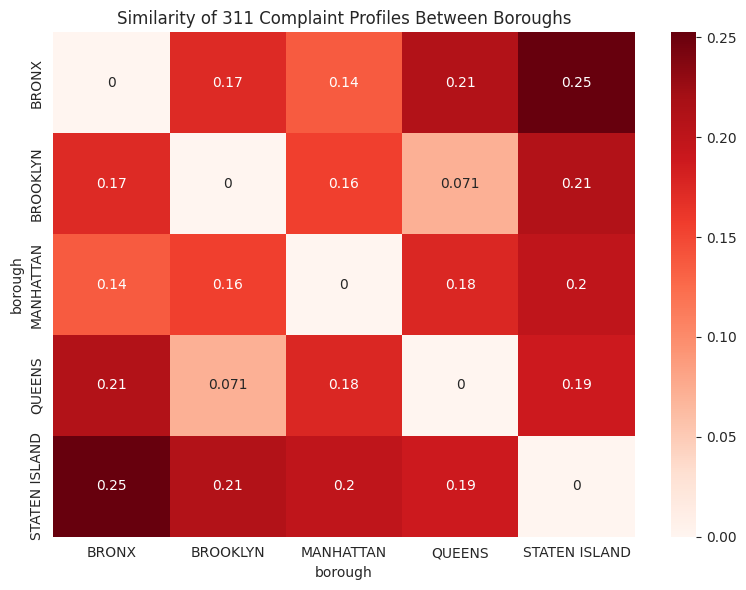

In [ ]:
# Visualization 3 - Complaint  profile similarity 

# Create borough-by-complaint proportion matrix
profile_matrix = borough_complaints.pivot(
    index='borough',
    columns='complaint_type',
    values='proportion'
).fillna(0)

# Compute distance between boroughs
distance_matrix = pd.DataFrame(
    squareform(pdist(profile_matrix, metric='euclidean')),
    index=profile_matrix.index,
    columns=profile_matrix.index
)

plt.figure(figsize=(8,6))
sns.heatmap(distance_matrix, annot=True, cmap='Reds')
plt.title("Similarity of 311 Complaint Profiles Between Boroughs")
plt.tight_layout()
plt.show()

Interpretation of Visualization 3: The similarity heatmap shows that Brooklyn and Queens have relatively similar complaint profiles, while the Bronx and Staten Island appear more distinct. The Bronx stands apart due to its high concentration of housing-related complaints, while Staten Island shows a different mix emphasizing street and waste issues. All of this highlights how the boroughs exhibit unique 311 service request signatures.

## Written Summary

Summarize your key findings here. What patterns did you discover? What can you conclude?

### Research Question and Motivation

- Why is this question interesting? 
- What might we learn?

This analysis explores whether NYC boroughs exhibit distinctive patterns in their 311 service requests by comparing the relative frequency of complaint types. This question is interesting because 311 data reflects residents’ everyday concerns and interactions with city services. By examining differences in complaint composition, we can learn how neighborhood conditions, housing, density, and infrastructure vary across boroughs.

### Methods

Describe your data source, cleaning steps, and analytical approach

I used NYC Open Data 311 Service Request records retrieved through the Socrata API, focusing on complaints created in 2023. Due to dataset size, I limited the sample to 100,000 records. After cleaning the data by removing missing key variables and restricting observations to the five NYC boroughs, I calculated complaint counts by borough and converted them into proportions. I then used visualizations, including a heatmap and stacked bar chart, to compare complaint distributions across boroughs.

### Findings

Summarize key patterns and statistical results (refer to your key visualizations)

The visualizations reveal clear differences in complaint composition across boroughs. The stacked bar chart shows that the Bronx is heavily dominated by HEAT/HOT WATER complaints, which make up a substantially larger share of total requests there than in other boroughs. In contrast, Brooklyn and Queens have the largest share of Illegal Parking complaints, while Manhattan displays a comparatively higher proportion of noise-related complaints, including residential and street noise. Staten Island exhibits a different mix, with relatively greater emphasis on street and sanitation-related issues.

The heatmap of complaint proportions further highlights these contrasts by showing variation in the intensity of specific complaint types across boroughs. Differences in shading show that boroughs aren't uniform in their service request patterns; instead, certain complaint types are disproportionately concentrated in particular areas.

All together, these visualizations highlight how boroughs differ not only in total complaint volume but in the relative composition of issues reported, supporting the conclusion that NYC boroughs exhibit distinct 311 service request “signatures.”

### Limitations

Discuss methodological limitations. What are the potential biases in 311 data? What alternative explanations exist for your findings? What can and cannot be concluded from this analysis?

311 data reflects reported complaints, not necessarily objective conditions. Reporting behavior may vary by income, language, trust in government, or access to technology, which could bias the observed patterns. Additionally, this analysis uses a limited sample of 2023 data rather than the full dataset, and borough-level aggregation may mask variation within neighborhoods. The analysis identifies associations but can't determine the underlying causes of these differences.

### Ethical Considerations

Reflect on the ethical implications of using 311 data:
- Who is represented in this data? Who might be underrepresented?
- What are potential privacy concerns?
- How might this analysis be used or misused?
- What are the implications for equity and justice?

311 data represents residents who choose and are able to report issues, meaning some communities may be underrepresented. Lower-income, elderly, undocumented, or non-English-speaking residents may be less likely to file complaints, which impacts the conclusions we can make about neighborhood conditions.

Although the dataset doesn't include identifying information in this analysis, geographic information can still raise privacy concerns. Additionally, analyses like this could be misused to label neighborhoods negatively without accounting for structural inequalities.

For equity and justice, it's important to interpret 311 patterns carefully and recognize that complaint frequency reflects both lived conditions and access to civic reporting systems.

## AI Appendix (if applicable)

If you used AI during this assignnment, explain
1. what part of the work it was used for; 
2. what AI tools you used; 
3. the prompts you used; 
4. how you analyzed the AI work for accuracy; and, 
5. steps you took to rework and revise your final documents so that they were both factually accurate and reflected your own voice and style.


## Submission

Submit your assignment as .ipynb file. Make sure to double check with the assignment instructions on Canvas.